In [1]:
#MakeMore Part3开启！
#这一部分和part2那样新开一个notebook不太一样，andrej会直接在part2的基础上继续添加东西
#直接开始吧

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
#环境导入，和之前的环境是一样的，前两行是torch，后两行是画图工具

In [3]:
words=open("names.txt","r").read().splitlines()
words[:3]
#还是一样导入words

['emma', 'olivia', 'ava']

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)
vocab_size=len(itos)
#还是一样建立字符数字表
#只不过直接生成好vocab_size

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [8]:
#构建训练集，验证集，测试集
#直接复制过来就好
block_size=3

def build_dataset(words,block_size):#依据words构建数据集的函数
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)#打印数据集的大小
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2],block_size)#80%~90%
Xte, Yte = build_dataset(words[n2:],block_size)#90~100%

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [9]:
#先生成神经网络
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：11897


In [10]:
#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

      0/ 200000:21.3397
  10000/ 200000:2.9612
  20000/ 200000:2.8091
  30000/ 200000:2.3070
  40000/ 200000:2.7541
  50000/ 200000:2.5519
  60000/ 200000:2.2964
  70000/ 200000:2.2251
  80000/ 200000:2.0623
  90000/ 200000:2.4373
 100000/ 200000:2.3082
 110000/ 200000:2.0747
 120000/ 200000:2.1816
 130000/ 200000:2.2747
 140000/ 200000:1.5415
 150000/ 200000:1.9268
 160000/ 200000:2.1260
 170000/ 200000:2.3212
 180000/ 200000:2.1252
 190000/ 200000:1.9200


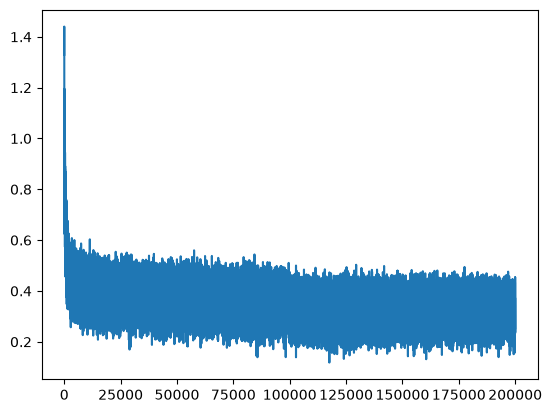

In [11]:
plt.plot(lossi)

In [14]:
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.1355013847351074
val 2.1711013317108154


In [18]:
#采样部分，和之前是一样的，只不过我们不用多层神经网络
g = torch.Generator().manual_seed(2147483647+10)#换个种子

for i in range(20):#生成20个名字
    context=[0]*block_size#上下文。由于我们所有名字的开头全部都是一串点，所以我们可以直接用这个
    out=[]#输出

    while True:#用循环来生成姓名，直到出现'.'
        emb = C[torch.tensor([context])] 
        embcat = emb.view(1, -1) 
        h = torch.tanh(embcat @ W1 + b1) 
        logits = h @ W2 + b2 # (N, vocab_size)
        probs=F.softmax(logits,dim=1)#loss的计算用的是cross_entropy，现在用softmax计算probs
        ix=torch.multinomial(probs,num_samples=1,generator=g).item()#根据概率输出词汇
        context=context[1:]+[ix]
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(s for s in out))

carmahzabelle.
khi.
mili.
taty.
skanden.
jazhien.
delynn.
jarqui.
nellara.
chaiiv.
kaleigh.
ham.
join.
quint.
shon.
walianni.
wazelo.
dearyxi.
jacee.
dus.


In [19]:
#我们现在要改进我们的神经网络
#所以第一步就是：先看看他有什么问题
#首先我们会发现：我们一开始的loss出奇的高
#我们来预估一下如果一个均匀分布的loss是多少
#loss是概率的负对数似然
#所以就是
-torch.tensor(1.0/27.0).log()

tensor(3.2958)

In [23]:
#所以其实我们的loss一开始能到20多是完全没有道理的
#很可能是因为我们的一开始随机出来的参数导致了非常大的偏差
#我们用一个直观的例子
logits=torch.tensor([0.0,0.0,0.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
probs,loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [24]:
#这就是均匀分布出来的loss，当我们调大某个值

#调大错误答案
logits=torch.tensor([0.0,5.0,0.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
print("错误情况：",loss)

#调大正确答案
logits=torch.tensor([0.0,0.0,5.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
print("正确情况：",loss)

错误情况： tensor(5.0200)
正确情况： tensor(0.0200)


In [25]:
#可以看到差距非常巨大

In [26]:
#所以我们回过头来看看一开始为什么会出现这种情况
#先生成神经网络
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

    break#直接break去观察logits

总参数量：11897
      0/ 200000:21.3397


In [27]:
#21，非常高
#我们来观察下具体的logits
logits[0]

tensor([-11.4648,  -2.3577, -19.8968, -11.0013,  -0.5254,  -4.8786,  -8.6600,
         14.3362,  -5.2337,   6.3359, -14.4392,  -1.8999,   4.7584,   5.3903,
         -2.7017,  -1.6146,  13.4166,   3.0630,  11.6902,  -7.2495,   9.3323,
          9.4472,  -1.5167,   7.1925,  -9.3888,   4.9943, -10.3481],
       grad_fn=<SelectBackward0>)

In [28]:
#可以看到我们会出现一些非常大的数字，甚至有不少超过10的，那么我们的loss直接打到20多的数值也就不奇怪了

In [30]:
#我们思考一下为什么会出现这个问题：
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True
#这是我们的神经网络
#只有这里涉及到了randn的赋值
#我们先来看看这里会生成什么样的数值
C[0]

总参数量：11897


tensor([ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,  0.6049,
         0.0791,  0.9046], grad_fn=<SelectBackward0>)

In [38]:
#其实还好，对吧？
#这里会按照正态分布在0附近进行分布
#但是在这个过程中会涉及好几次乘法加法
#于是这种值会逐渐累加导致最后变得非常夸张
#所以我们的第一个思路就是：神经网络在初始化的时候缩放的小一些

g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#隐藏层
b1 = torch.randn(n_hidden,                     generator=g)#隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.1#激活层
b2 = torch.randn(vocab_size,                   generator=g)*0#激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：11897


In [39]:
#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

      0/ 200000:3.7328
  10000/ 200000:2.4668
  20000/ 200000:2.4029
  30000/ 200000:2.0175
  40000/ 200000:2.3921
  50000/ 200000:2.3864
  60000/ 200000:2.1833
  70000/ 200000:1.9166
  80000/ 200000:2.0670
  90000/ 200000:2.3476
 100000/ 200000:1.9745
 110000/ 200000:1.9660
 120000/ 200000:2.1251
 130000/ 200000:2.1283
 140000/ 200000:1.6356
 150000/ 200000:1.9641
 160000/ 200000:2.1418
 170000/ 200000:2.2065
 180000/ 200000:2.2229
 190000/ 200000:1.8492


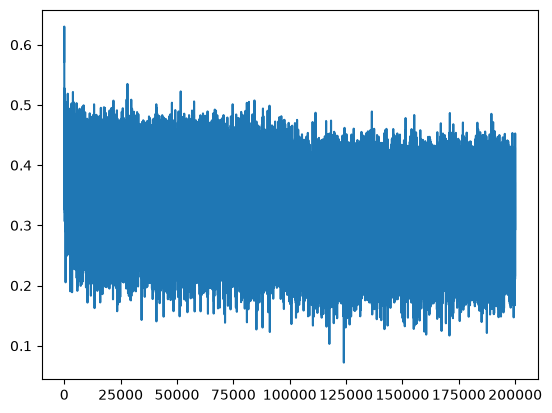

In [40]:
plt.plot(lossi)

In [41]:
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.066411018371582
val 2.1285133361816406


In [42]:
#loss有微弱的下降
#并且我们的训练曲线不再是“曲棍球棒”形状了
#也就是说我们跳过了一开始loss急剧下降的压缩阶段

In [43]:
#好的接下来，优化完了这个神经网络，我们可以再看一下更深层的东西：h
#我们把这个h单独拎出来
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#隐藏层
b1 = torch.randn(n_hidden,                     generator=g)#隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.1#激活层
b2 = torch.randn(vocab_size,                   generator=g)*0#激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())
    break

h

总参数量：11897
      0/ 200000:3.7328


tensor([[ 0.9923, -0.9907, -1.0000,  ..., -0.9999, -0.9476,  0.9999],
        [-1.0000, -0.8721, -0.3894,  ...,  1.0000, -0.5784,  1.0000],
        [-1.0000,  0.9078, -1.0000,  ...,  0.9976, -1.0000,  0.7278],
        ...,
        [-1.0000,  0.9962, -1.0000,  ...,  1.0000, -0.9986,  0.7845],
        [ 0.9991,  0.9485, -0.9999,  ..., -0.1299, -1.0000,  0.9104],
        [-0.9986,  0.9628, -0.4524,  ...,  0.9527, -0.9987,  0.9871]],
       grad_fn=<TanhBackward0>)

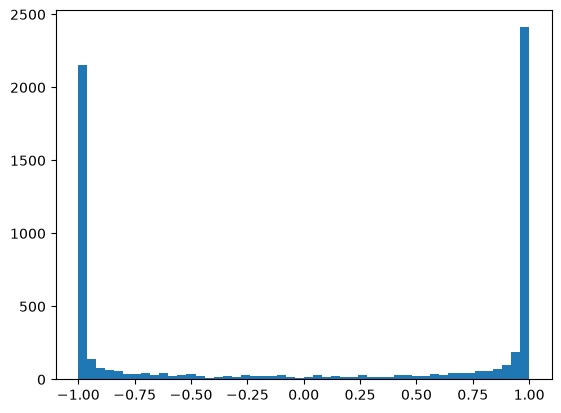

In [56]:
#我们会发现一个问题：就是h里有很多的值是1或-1或者非常接近这两个值
plt.hist(h.view(-1).tolist(),50);#这个可以生成h的直方图

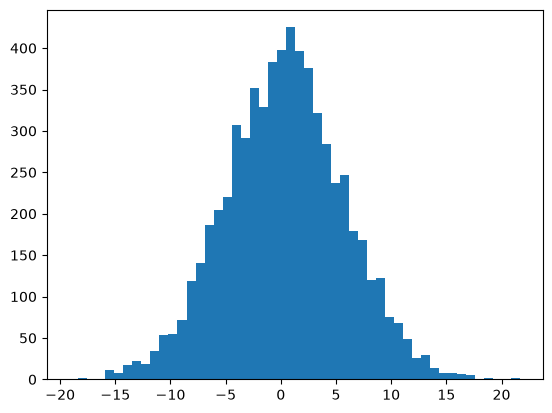

In [57]:
#这个是不是很直观，h的分布非常不健康
#所以我们来看看k接收的输入hpreact长什么样
plt.hist(hpreact.view(-1).tolist(),50);

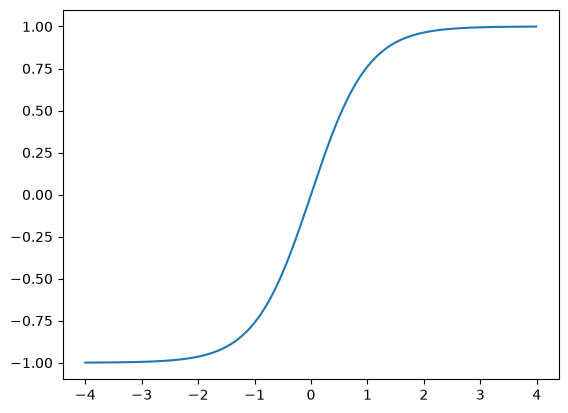

In [55]:
#其实还好，是吧？基本符合正态分布，因为我们之前就是用正态分布生成的神经网络
#但是hpreact到h的计算是tanh
#还记得tanh长什么样子吗？
import math
ii=[]
tanh=[]
for i in range(-400,400,1):
    tanh.append(math.tanh(i/100))
    ii.append(i/100)

plt.plot(ii,tanh)

In [50]:
#这个是tanh的函数曲线
#我们可以发现：大概在3左右tanh就已经非常逼近1了
#所以当h接收了hpreact之后就非常容易出现这种数值过大或者过小导致精度丢失的问题

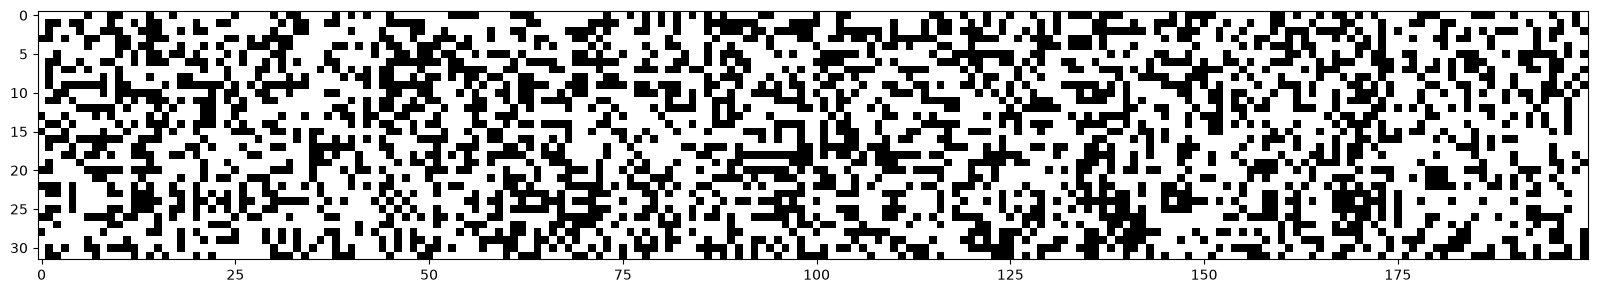

In [63]:
#那么这个会有什么问题呢？
#回忆一下micrograd
#我们的调整方式是梯度下降法。
#但是我们来观察一下这个tanh函数接近1之后的梯度长什么样：
#几乎是0
#也就是说：当我们的h趋近于1或者-1的时候：我们的grad调不动他了
#甚至可能会出现grad卡死的情况：因为精度不够导致梯度直接被看成了0
#我们来观察一下有多少的h处于这种极端区间（绝对值>0.99）
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')#在这里符合最前面那个标准的会显示为白色

In [78]:
#可以发现几乎一大半的参数都显示为超过0.99
#这就是大麻烦：这种神经元无法进行梯度更新，也就是说会变成“死亡神经元”
#这种神经元学不到东西 
#同时这种情况也很可能出现在训练过程中：
#因为训练过程如果步长设置的太大的话，可能会导致我们的h一脚直接踏到了“死亡区”
#这就是训练中的“脑损伤”
#有时候出现这种情况就会发现有的神经元从来没有被激活过，也就是再也不该变了
#这个时候这个神经元就“死亡”了

#所以这样看其实有个很简单的方法：我们直接把之前的参数初始值再调低一点就可以了


g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*0.2      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())
    break

h

总参数量：11897
      0/ 200000:3.2946


tensor([[ 0.7395, -0.3359, -0.8418,  ..., -0.8057, -0.1238,  0.7084],
        [-0.9795, -0.0808, -0.0881,  ...,  0.8813,  0.1048,  0.9167],
        [-0.9610,  0.4544, -0.7984,  ...,  0.5472, -0.7981,  0.0804],
        ...,
        [-0.9851,  0.6709, -0.9547,  ...,  0.8741, -0.4529,  0.1067],
        [ 0.8225,  0.5010, -0.7836,  ..., -0.0837, -0.8682,  0.1990],
        [-0.3225,  0.5256, -0.1033,  ...,  0.3043, -0.4624,  0.3795]],
       grad_fn=<TanhBackward0>)

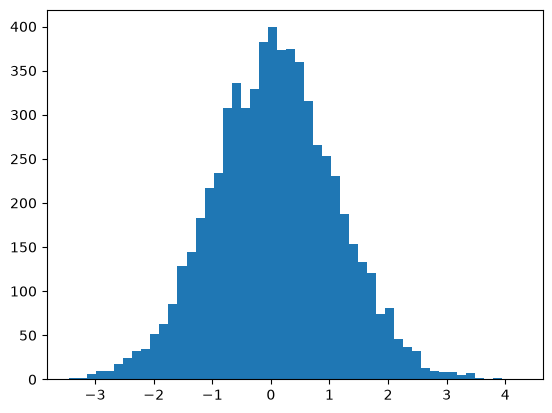

In [79]:
#这样是不是好了很多？
plt.hist(hpreact.view(-1).tolist(),50);

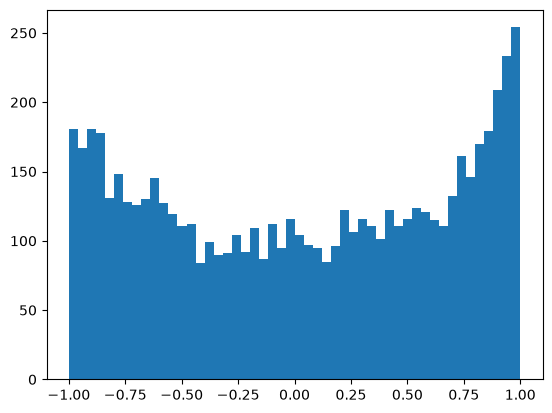

In [80]:
plt.hist(h.view(-1).tolist(),50);

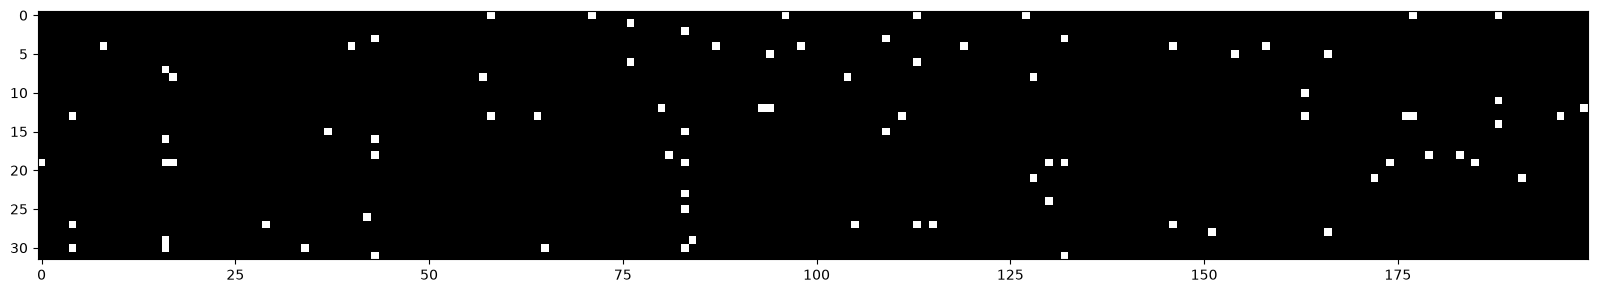

In [81]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')

In [82]:
#可以看到现在之后很少的白点了，而且h的分布比较均匀了

In [83]:
#现在来完整训练
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*0.2      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(1,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

总参数量：11897
      0/ 200000:3.2946
  10000/ 200000:2.3933
  20000/ 200000:2.1144
  30000/ 200000:2.0846
  40000/ 200000:2.2761
  50000/ 200000:2.3063
  60000/ 200000:2.0562
  70000/ 200000:2.0722
  80000/ 200000:1.9796
  90000/ 200000:2.2532
 100000/ 200000:1.9250
 110000/ 200000:1.9280
 120000/ 200000:2.0526
 130000/ 200000:2.1267
 140000/ 200000:1.4315
 150000/ 200000:1.9000
 160000/ 200000:2.2105
 170000/ 200000:2.1831
 180000/ 200000:2.1566
 190000/ 200000:1.8176


In [84]:
#重新评估一下
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.0349888801574707
val 2.1028261184692383


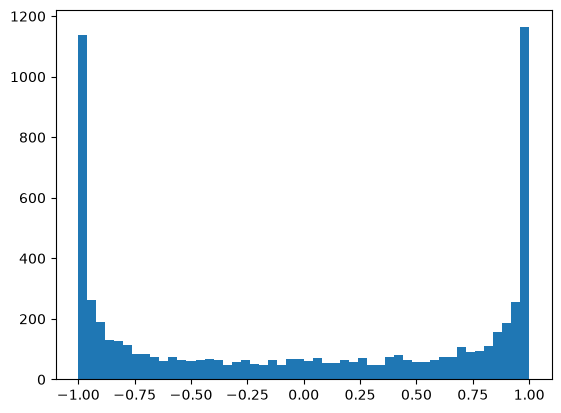

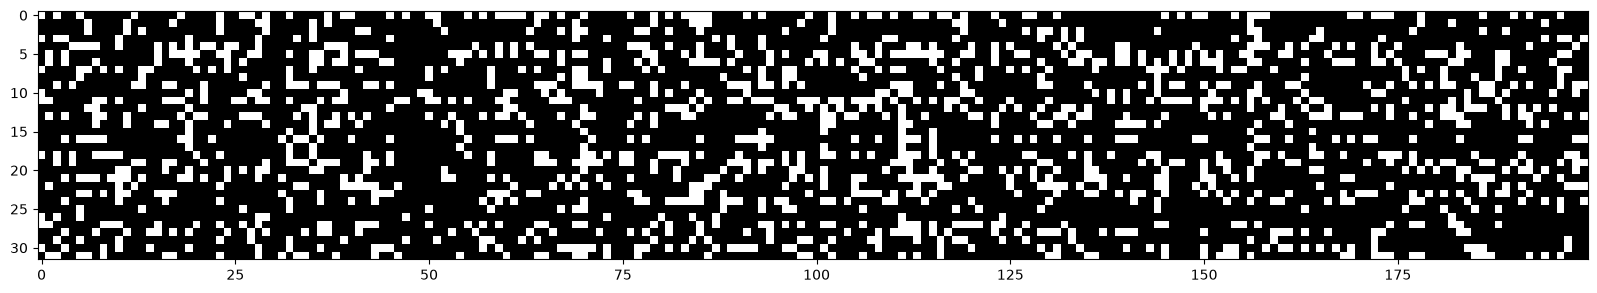

In [85]:
#可以看到loss又下降了一点
#我们看看训练后的h长什么样
plt.hist(h.view(-1).tolist(),50);
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')

In [87]:
#可以看到还是会有有的h会损伤，但是明显比之前初始化时候出现的大片白色好多了
#可能有同学会觉得我们的优化非常简单，但事实上是因为我们的模型非常简单，导致一开始这些问题就不是很严重
#那我们现在来试试看我们上次写的那个多层的模型